# Mandelbrot Set

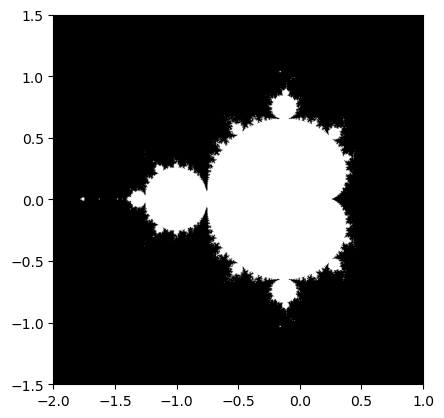

Mandelbrot image saved as mandelbrot.png


In [63]:
import numpy as np
import matplotlib.pyplot as plt

x_min = -2.0
x_max = 1.0
y_min = -1.5
y_max = 1.5

# number of grid points for resolution
points = 800

threshold = 50
N_max = 50

x, y = np.mgrid[x_min:x_max:complex(points), y_min:y_max:complex(points)]
c = x + 1j * y

# to check for points still inside
z = np.zeros_like(c, dtype = complex)
mask = np.ones(c.shape, dtype = bool)

# z = z^2 + c
for n in range(N_max):
    
    z[mask] = z[mask] ** 2 + c[mask]

    # check which points are not in
    mask[np.abs(z) > threshold] = False

# points that still inside
M = mask

# plot the result
plt.imshow(mask.T, extent=[x_min, x_max, y_min, y_max])
plt.gray() 
plt.savefig("mandelbrot.png")
plt.show()

print("Mandelbrot image saved as mandelbrot.png")


# Markov Chain

In [65]:
P = np.random.rand(5, 5)
for i in range(5):
    P[i, :] = P[i, :] / np.sum(P[i, :])  # normalize each row

# check row sums
print("Row sums of P:", np.sum(P, axis=1))

print("Transition matrix P: \n", P)

Row sums of P: [1. 1. 1. 1. 1.]
Transition matrix P: 
 [[0.185886   0.23479518 0.21161908 0.17095914 0.1967406 ]
 [0.26786591 0.1360298  0.16564356 0.16225651 0.26820422]
 [0.27648832 0.23133941 0.14110988 0.25783083 0.09323156]
 [0.1535145  0.26471002 0.21555108 0.11599302 0.25023138]
 [0.29089294 0.22226209 0.23442844 0.20668796 0.04572856]]


In [66]:
# make a random probability vector and normalize it
p = np.random.rand(5)
p = p / np.sum(p)

print("Initial probability vector p:", p) 

print("Sum of p =", np.sum(p))

Initial probability vector p: [0.34977973 0.22693891 0.04664665 0.314149   0.06248571]
Sum of p = 0.9999999999999999


In [67]:
# apply the transition rule 50 times
for n in range(50):
    p = np.dot(P.T, p)

print("Probability vector after 50 transitions (p50):", p)
print("Sum =", np.sum(p))

Probability vector after 50 transitions (p50): [0.23359646 0.21603968 0.19280989 0.18208916 0.1754648 ]
Sum = 1.0000000000000002


In [68]:
# stationary distribution
eig_vals, eig_vecs = np.linalg.eig(P.T)  

# find which eigenvalue is closest to 1
for i in range(len(eig_vals)):
    if abs(eig_vals[i] - 1) < 10**-5:
        v = eig_vecs[:, i]              
        break

# make sure the numbers are real
v = np.real(v)

# normalize so all entries add up to 1
v = v / np.sum(v)


print("Stationary distribution v:", v)
print("Sum =", np.sum(v))

Stationary distribution v: [0.23359646 0.21603968 0.19280989 0.18208916 0.1754648 ]
Sum = 0.9999999999999999


In [69]:
# compare p50 and v
difference = np.abs(p - v)
print("Difference between p50 and v:", difference)


if np.all(difference < 10**-5):
    print("Does match")
else:
    print("Does not match")

Difference between p50 and v: [0.00000000e+00 2.77555756e-17 5.55111512e-17 8.32667268e-17
 1.66533454e-16]
Does match


# Taylor Series Approximation

In [70]:
import time
import math
import numpy as np
import pandas as pd
import sympy as sp
import matplotlib.pyplot as plt

In [71]:
def taylor_approx(func, start, end, degree, fixed_c, num_points = 100):
    x = sp.symbols('x')

    # make 100 x
    xs = np.linspace(start, end, num_points)

    coeffs = []
    for n in range(degree + 1):
        # take the nth derivative of the function
        fn = sp.diff(func, x, n)
        # plug in x 
        fn_c = float(fn.subs(x, fixed_c))
        # divide by n!
        a_n = fn_c / math.factorial(n)
        coeffs.append(a_n)

    approx = np.zeros_like(xs, dtype=float)
    for n, a_n in enumerate(coeffs):
        approx += a_n * (xs - fixed_c)**n

    # return only the approximation points
    return approx


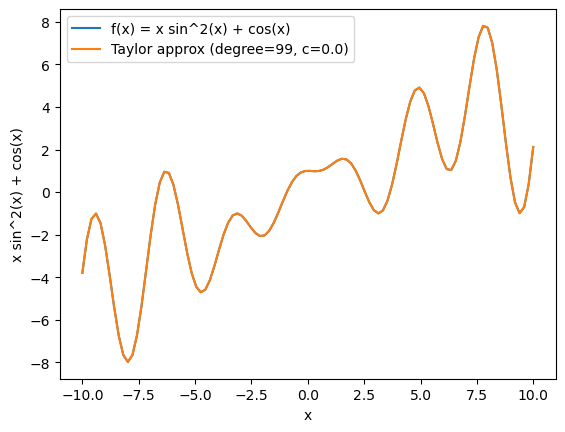

In [72]:
x = sp.symbols('x')
func = x*sp.sin(x)**2 + sp.cos(x)

start = -10
end = 10
degree = 99
fixed_c = 0.0

xs = np.linspace(start, end, 100)
approx = taylor_approx(func, start, end, degree, fixed_c)

f_np = sp.lambdify(x, func, "numpy")
y_true = f_np(xs)

plt.plot(xs, y_true, label="f(x) = x sin^2(x) + cos(x)")
plt.plot(xs, approx, label=f"Taylor approx (degree={degree}, c={fixed_c})")
plt.xlabel("x")
plt.ylabel("x sin^2(x) + cos(x)")
plt.legend()
plt.show()


In [73]:
def taylor_factorial(func, start, end, fixed_c, initial_degree, final_degree, degree_step):

    x = sp.symbols('x')
    xs = np.linspace(start, end, 100)
    f_np = sp.lambdify(x, func, "numpy")
    y_true = f_np(xs)

    results = []

    for m in range(initial_degree, final_degree + 1, degree_step):
        t0 = time.time() # count time
        y_hat = taylor_approx(func, start, end, m, fixed_c)   # aprox
        elapsed = time.time() - t0 # count time

        total_abs_error = float(np.sum(np.abs(y_true - y_hat))) # absolute difference

        results.append({
            "degree": m,
            "total_abs_error": total_abs_error,
            "seconds": elapsed
        })

    df = pd.DataFrame(results, columns=["degree", "total_abs_error", "seconds"])
    df.to_csv("taylor_values.csv", index=False)
    print("Saved: taylor_values.csv")
    print(df)


In [74]:
x = sp.symbols('x')
func = x*sp.sin(x)**2 + sp.cos(x)

start = -10
end = 10
fixed_c = 0.0
initial_degree = 50
final_degree = 100
degree_step = 10

taylor_factorial(func, start, end, fixed_c, initial_degree, final_degree, degree_step)


Saved: taylor_values.csv
   degree  total_abs_error   seconds
0      50     4.949573e+01  0.051888
1      60     1.753924e-03  0.038312
2      70     3.444162e-07  0.034251
3      80     3.326286e-07  0.038857
4      90     3.326287e-07  0.044844
5     100     3.326287e-07  0.051171
